In [1]:
#utils I made to look at this data
import switchy.util as ut
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
import scanpy as sc
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import autoreload
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 300
   }

mpl.rcParams.update(params)

sns.set_style("ticks")

savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": True}
mpl.rc('savefig', dpi=300)
output_dir = "outs"
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

data_dir = "../data/"
#import auto reload
%load_ext autoreload
%autoreload 2

In [2]:
sc.set_figure_params(color_map='viridis')

# Load Data and filter

In [3]:
adata = sc.read_h5ad('/home/mswift/B_cells/CSR/switchy/data/CombinedDivisionImmcantation.h5ad')

In [4]:
adata = ut.preprocessScanpy(adata, num_counted_reads=80000, num_genes=500, min_cells=30, n_neighbors=15, num_highly_variable=2000)

making var_names unique
filtering cells with less than 80000 counted reads
filtering cells with less than 500 genes detected
filtering genes detected in less than 30
normalizing by total counts per cell
log transforming data
removed ERCC sequences from genes to cluster on
removing variable immune receptor genes which may drive clustering
calculating highly variable genes


Trying to set attribute `.var` of view, copying.


calculating PCA
creating neighbors graph with 15


/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scanpy/neighbors/__init__.py:121: FutureWarning: This location for 'distances' is deprecated. It has been moved to .obsp[distances], and will not be accesible here in a future version of anndata.
  adata.uns['neighbors']['distances'] = neighbors.distances
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scanpy/neighbors/__init__.py:122: FutureWarning: This location for 'connectivities' is deprecated. It has been moved to .obsp[connectivities], and will not be accesible here in a future version of anndata.
  adata.uns['neighbors']['connectivities'] = neighbors.connectivities
/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scanpy/tools/_umap.py:147: FutureWarning: This location for 'connectivities' is deprecated. It has been moved to .obsp[connectivities], and will not be accesible here in a future version of anndata.
  adata.uns['neighbors']['connectivities'].tocoo()

umapping and tsne-ing


In [5]:
sc.tl.leiden(adata, resolution = 0.3)

/home/mswift/local/anaconda3/envs/singlecell/lib/python3.6/site-packages/scanpy/tools/_leiden.py:111: FutureWarning: This location for 'connectivities' is deprecated. It has been moved to .obsp[connectivities], and will not be accesible here in a future version of anndata.
  adjacency = adata.uns['neighbors']['connectivities']


# Correlation Analysis

In [10]:
# Try to remove the ERCCs
_adata = sc.read_h5ad('/home/mswift/B_cells/CSR/switchy/data/CombinedDivisionImmcantation.h5ad')

ERCCs = _adata.var.index[_adata.var.index.str.contains("ERCC-|NIST")].to_list()

_adata = _adata[:, ~_adata.var.index.isin(ERCCs)]

In [11]:
sc.pp.filter_cells(_adata, min_counts=80000, inplace=True)
sc.pp.filter_genes(_adata, min_cells=150, inplace=True)

Trying to set attribute `.obs` of view, copying.


In [12]:
sc.pp.normalize_total(_adata, exclude_highly_expressed=True, inplace=True, target_sum=1e6)

In [13]:
# Get raw df with cells and genes 

df = pd.DataFrame(_adata.X)
df.set_index(_adata.obs.index, inplace = True)
df.columns = _adata.var.index
# Log 10 transform it 
df_log = np.log10(df + 1)

In [14]:
# Use Numpy to do the Pearson Correllation of all values
# Did this because pandas corr is very slow, must be a bug.. 
df_corr = np.corrcoef(df_log.values, rowvar=False) 

# Put the labels back on and make it a df
df_corr = pd.DataFrame(df_corr, index = df_log.columns, columns=df_log.columns)

# Check that the matrix looks correct
df_corr.head()

,WASH7P,FO538757.1,MTND1P23,MTND2P28,ENSG00000276171,MTCO1P12,MTCO2P12,MTATP8P1,MTATP6P1,MTCO3P12,AL669831.5,LINC01128,NOC2L,ISG15,AL390719.1,C1orf159,SDF4,B3GALT6,UBE2J2,PUSL1,INTS11,CPTP,AURKAIP1,CCNL2,AL391244.1,MRPL20,ATAD3B,ATAD3A,SSU72,MIB2,CDK11B,SLC35E2B,CDK11A,AL031282.2,SLC35E2,NADK,GNB1,FAAP20,MORN1,RER1,PEX10,PANK4,TNFRSF14-AS1,TNFRSF14,FAM213B,TPRG1L,WRAP73,TP73-AS1,LRRC47,CEP104,DFFB,C1orf174,KCNAB2,RPL22,ICMT,ACOT7,NOL9,AL591866.1,ZBTB48,KLHL21,PHF13,THAP3,DNAJC11,CAMTA1,VAMP3,TNFRSF9,PARK7,RERE,ENO1,HMGN2P17,SLC2A5,H6PD,SLC25A33,AL954705.1,TMEM201,PIK3CD,PIK3CD-AS2,CLSTN1,CTNNBIP1,LZIC,NMNAT1,UBE4B,KIF1B,PGD,CENPS,DFFA,PEX14,CASZ1,TARDBP,SRM,EXOSC10,MTOR,UBIAD1,FBXO44,FBXO6,MAD2L2,AGTRAP,MTHFR,CLCN6,KIAA2013,PLOD1,MFN2,MIIP,TNFRSF8,TNFRSF1B,VPS13D,HNRNPCL1,PRDM2,EFHD2,CASP9,DNAJC16,CHCHD2P6,DDI2,PLEKHM2,RPL12P14,UQCRHL,AL450998.1,AL450998.2,SPEN,ZBTB17,FBXO42,SZRD1,NECAP2,NBPF1,ENSG00000282056,CROCCP2,EIF1AXP1,CROCC,SDHB,RCC2,ALDH4A1,IFFO2,UBR4,EMC1,MRTO4,AKR7A2,PQLC2,CAPZB,MINOS1,AL031727.1,TMCO4,OTUD3,MUL1,DDOST,HP1BP3,EIF4G3,ECE1,NBPF3,ALPL,USP48,AL590556.1,LINC00339,CDC42,ZBTB40,KDM1A,LUZP1,HNRNPR,E2F2,ID3,RPL11,ELOA,PITHD1,LYPLA2,GALE,HMGCL,FUCA1,CNR2,AL590609.2,PNRC2,SRSF10,IFNLR1,STPG1,NIPAL3,RCAN3,SRRM1,CLIC4,RUNX3,SYF2,RSRP1,SDHDP6,TMEM50A,AL031284.1,MACO1,SELENON,MTFR1L,AUNIP,PAQR7,STMN1,CEP85,SH3BGRL3,UBXN11,CD52,DHDDS,AL513365.1,HMGN2,RPS6KA1,ARID1A,PIGV,ZDHHC18,GPN2,GPATCH3,NUDC,RPL12P13,OSTCP2,SLC9A1,CHCHD3P3,NPM1P39,WDTC1,TMEM222,ACTG1P20,SYTL1,MAP3K6,WASF2,AL031729.1,IFI6,FAM76A,STX12,PPP1R8,THEMIS2,RPA2,XKR8,EYA3,SPCS2P4,PTAFR,DNAJC8,ATP5IF1,SESN2,MED18,PHACTR4,RCC1,SNHG3,SNORA73B,TRNAU1AP,SNHG12,SNORD99,TAF12,GMEB1,YTHDF2,EPB41,AL138785.1,SRSF4,MECR,LAPTM5,PUM1,SNRNP40,ZCCHC17,PEF1,PTP4A2,KHDRBS1,TMEM39B,...,CBY1,TOMM22,JOSD1,GTPBP1,PRDX3P1,SUN2,CBX6,APOBEC3B,APOBEC3C,APOBEC3D,APOBEC3F,APOBEC3G,APOBEC3H,CBX7,RPL3,SYNGR1,TAB1,MGAT3,MIEF1,ATF4,RPS19BP1,UQCRFS1P1,Z82206.1,TNRC6B,ADSL,SGSM3,MKL1,SLC25A17,ST13,XPNPEP3,RBX1,AL080243.2,AL080243.1,EP300,L3MBTL2,RANGAP1,ZC3H7B,TOB2,PHF5A,ACO2,POLR3H,PMM1,DESI1,XRCC6,SNU13,C22orf46,MEI1,AL021453.1,SREBF2,TNFRSF13C,CENPM,NAGA,SNORD13P1,SMDT1,NDUFA6,OLA1P1,TCF20,RRP7A,RRP7BP,POLDIP3,CYB5R3,ATP5MGL,RPL5P34,ARFGAP3,PACSIN2,MCAT,TSPO,TTLL12,SAMM50,AL035398.1,PARVB,PARVG,RTL6,NUP50-AS1,NUP50,FAM118A,Z95331.1,ATXN10,PRR34-AS1,PPARA,CDPF1,TTC38,GTSE1,TRMU,CERK,AL118516.1,TBC1D22A,C22orf34,BRD1,ZBED4,ALG12,CRELD2,PIM3,TRABD,SELENOO,TUBGCP6,MAPK12,PLXNB2,DENND6B,PPP6R2,SBF1,ADM2,LMF2,NCAPH2,SCO2,TYMP,ODF3B,ARSA,AC002056.1,RPL23AP82,RABL2B,FP565260.6,FP565260.1,U2AF1L5,FP671120.3,FP671120.4,FP236383.2,FP236383.3,CR381670.1,TEKT4P2,EIF3FP1,ANKRD20A11P,AP001347.1,HSPA13,SAMSN1,NRIP1,USP25,BTG3,C21orf91,PPIAP22,EEF1A1P1,LINC01684,RPL13AP7,LINC00158,MIR155HG,MRPL39,JAM2,ATP5PF,GABPA,APP,GPX1P2,RPL10P1,N6AMT1,LTN1,RWDD2B,USP16,CCT8,BACH1,TIAM1,SOD1,SCAF4,MIS18A,URB1,URB1-AS1,C21orf59,SYNJ1,PAXBP1,IFNAR2,IL10RB,IFNAR1,IFNGR2,TMEM50B,GART,SON,DONSON,CRYZL1,ATP5PO,MRPS6,SLC5A3,RCAN1,CLIC6,RUNX1,SETD4,CBR1,MEMO1P1,CBR3-AS1,DOPEY2,MORC3,CHAF1B,CLDN14,HLCS,PIGP,TTC3,VPS26C,DYRK1A,PSMG1,BRWD1,HMGN1,WRB,MX2,MX1,PRDM15,ZBTB21,ZNF295-AS1,SLC37A1,WDR4,NDUFV3,PKNOX1,U2AF1,RRP1B,PDXK,CSTB,RRP1,AGPAT3,TRAPPC10,H2AFZP1,PWP2,C21orf33,PFKL,C21orf2,UBE2G2,SUMO3,PTTG1IP,ITGB2,ITGB2-AS1,FAM207A,ADARB1,SLC19A1,SPATC1L,LSS,MCM3AP-AS1,MCM3AP,YBEY,C21orf58,PCNT,DIP2A,PRMT2,MT-RNR1,MT-RNR2,MT-TL1,MT-ND1,MT-ND2,MT-TC,MT-TY,MT-CO1,MT-CO2,MT-ATP8,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,MT-TP,ENSG00000277048,AL592183.1,AC004556.1,AC240274.1
WASH7P,1.000000,0.347925,0.048526,-0.011657,-0.025707,0.021004,-0.055736,-0.037221,-0.009548,-0.061468,0.019476,0.073613,0.007615,-0.023639,0.019944,0.020153,0.029990,0.025007,0.054842,0.053248,0.003851,0.051060,0.043552,0.018483,0.022164,-0.004537,0.021548,0.029274,0.011433,0.028681,0.047787,-0.012396,0.009191,0.027626,0.019339,0.056495,0.000983,0.051922,-0.002802,-0.009182,0.010434,0.048073,-0.030160,0.041941,0.048710,0.036919,0.051209,0.025

In [16]:
# Bootstrap 
# Make a deep copy of the df_log so that I can shuffle AICDA Column
LiOfSerAICDA = [] 
_df = df_log.copy(deep = True)
for i in range(10): 
    np.random.shuffle(_df['AICDA'])
    _df_corr = np.corrcoef(_df.values, rowvar=False)
    _df_corr = pd.DataFrame(_df_corr, index = _df.columns, columns=_df.columns)
    LiOfSerAICDA.append(_df_corr['AICDA'])
    
df = pd.DataFrame(LiOfSerAICDA)
df.reset_index(inplace = True)
df.to_feather('test_df.fthr')    

(array([9.000e+00, 1.900e+01, 3.900e+01, 8.600e+01, 2.070e+02, 5.720e+02,
        1.135e+03, 1.779e+03, 1.875e+03, 1.462e+03, 1.098e+03, 8.450e+02,
        5.800e+02, 4.320e+02, 3.310e+02, 2.420e+02, 2.030e+02, 1.580e+02,
        1.050e+02, 8.100e+01, 3.600e+01, 2.300e+01, 1.000e+01, 6.000e+00,
        9.000e+00, 2.000e+00, 3.000e+00, 2.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00]),
 array([-0.2       , -0.17435897, -0.14871795, -0.12307692, -0.0974359 ,
        -0.07179487, -0.04615385, -0.02051282,  0.00512821,  0.03076923,
         0.05641026,  0.08205128,  0.10769231,  0.13333333,  0.15897436,
         0.18461538,  0.21025641,  0.23589744,  0.26153846,  0.28717949,
         0.31282051,  0.33846154,  0.36410256,  0.38974359,  0.41538462,
         0.44102564,  0.46666667,  0.49230769,  0.51794872,  0.54358974,
         0.56923077,  0.59487179,  0.62051282,  0.64615385,  0.67179487,
  

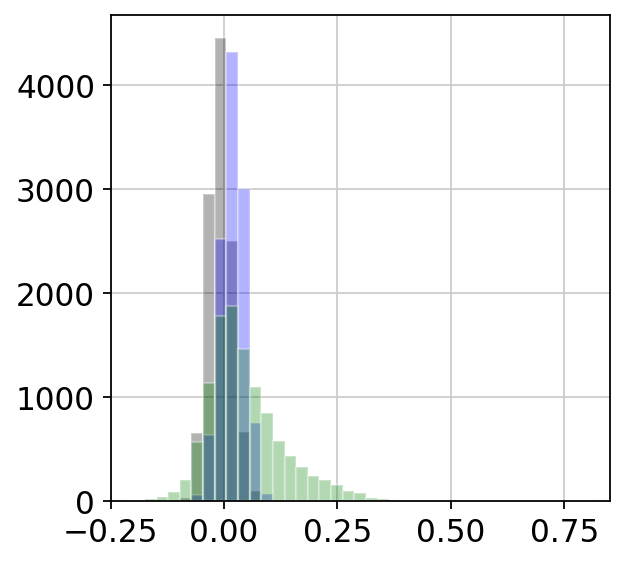

In [17]:
fig, ax = plt.subplots(1,1)
bins = np.linspace(-0.2, 0.8, 40)
plt.hist(LiOfSerAICDA[0], bins = bins, alpha = 0.3, color = 'k')
plt.hist(LiOfSerAICDA[1], bins = bins, alpha = 0.3, color = 'b')
plt.hist(df_corr['AICDA'], bins = bins, alpha = 0.3, color = 'g')

In [18]:
# B cell genes of interest! 
BCGs = ['AICDA', 'PRDM1', 'BACH2', 'ARID5A', 'CR2', 'ICOSLG', 'IL10']

### Plot the Distributions of Peason Correlation Coeffs

KeyError: 'ICOSLG'

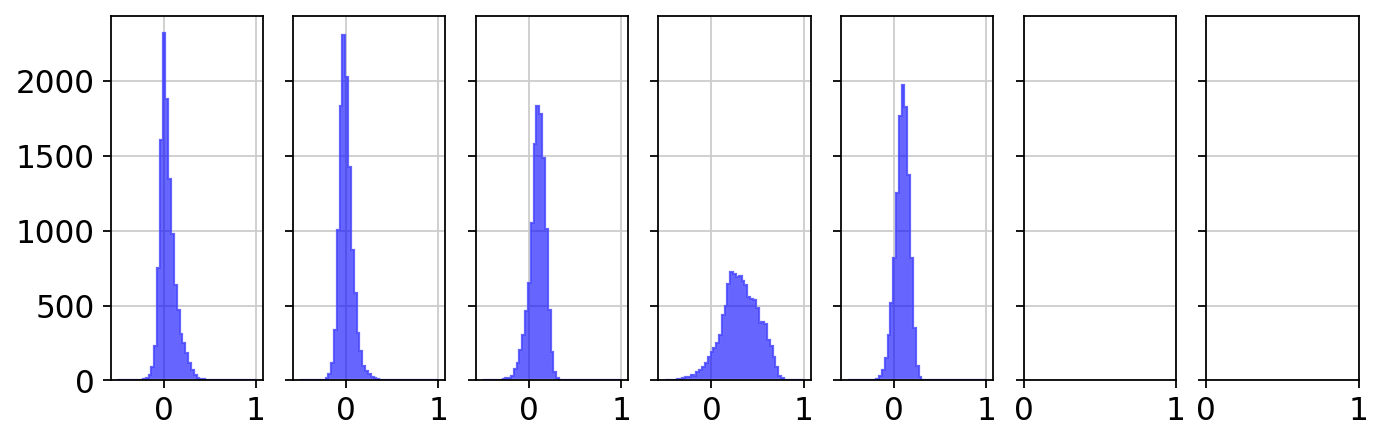

In [19]:
fig, ax = plt.subplots(1, len(BCGs), sharey = True, figsize = (10,3))

DictofSerGenes = {}
bins = np.linspace(-0.5, 1, 50)
for i, GOI in enumerate(BCGs):
    
    ax[i].hist(df_corr[GOI], histtype='stepfilled', alpha = 0.6,color = 'b' ,bins = bins)
    ax[i].hist(df_corr[GOI], histtype='step', alpha = 0.6, color = 'b', bins = bins)
    #Create a dictionary where the key is the gene of interest and the most correlated genes are the values 
    DictofSerGenes.update({GOI:df_corr[GOI].sort_values(ascending = False)[:500]})

In [38]:
# Just plot the GOI (Gene of Interest)

In [20]:
GOI = 'AICDA'
#GOI = 'ARID5A'


Text(0.5, 0, 'Pearson with AID')

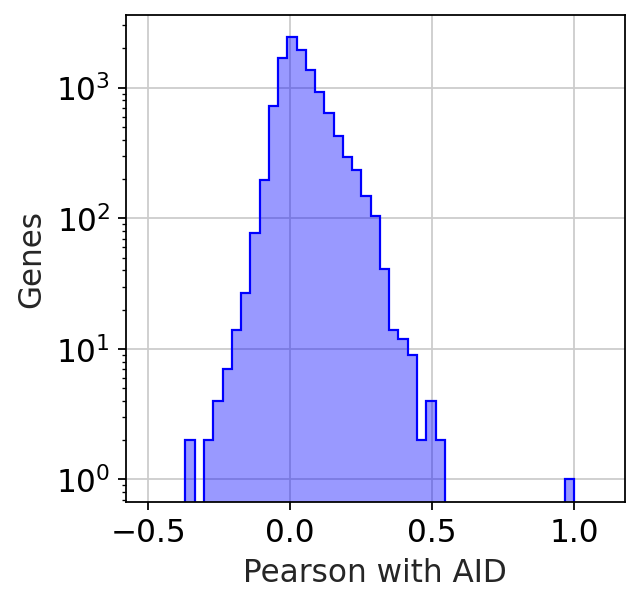

In [21]:
fig, ax = plt.subplots(1,1)

bins = np.linspace(-0.5, 1.1, 50)

plt.hist(df_corr[GOI], histtype='stepfilled', alpha = 0.4,color = 'b' ,bins = bins)
plt.hist(df_corr[GOI], histtype='step', alpha = 1, color = 'b', bins = bins)

plt.yscale('log')
plt.ylabel('Genes')
plt.xlabel('Pearson with AID')

In [22]:
# For GOI take the top 500 Pearson Correlated Genes
TopPearson = DictofSerGenes[GOI][:1000].index.to_list()

In [23]:
DictofSerGenes[GOI]

AICDA              1.000000
MIR4435-2HG        0.543543
AC017002.3         0.517093
MSC                0.500490
TOX2               0.491174
HSPB1              0.483207
GCSAM              0.480574
IGHG2              0.465650
AC012236.1         0.464583
CLECL1             0.438891
LINC01943          0.436501
KCNMA1             0.424752
TNFRSF17           0.424544
TVP23A             0.423491
IGHG1              0.422790
TCTN1              0.420139
HSPB1P1            0.420129
TOX                0.418460
CADM1              0.409615
ENSG00000275301    0.404976
BEX3               0.403275
JCHAIN             0.399534
WDR66              0.395755
LINC00864          0.390734
GPX1P1             0.389313
HLA-DQB1           0.388761
SCARNA22           0.387488
FAM171B            0.385319
POU2AF1            0.384979
SLC41A1            0.383247
SPATC1L            0.377174
GLRX               0.374578
TBCA               0.370569
SEC11C             0.364678
NDUFAF3            0.363249
GSTP1              0

In [24]:
# Transform the Raw Data TODO: Refactor to make this happen only once and early
gene_df = df_log

In [25]:
# Subset the Df by these genes in order to make the spearman calculation manageable
small_df = gene_df[TopPearson]

In [26]:
# Spearman Corr of the genes with each other amongts all the cells 
df_spear =  small_df.corr(method='spearman')

In [40]:
AICDA_genes = df_spear[df_spear['AICDA'] > 0.3]['AICDA']

In [41]:
for i in AICDA_genes.index:
    print(i)

AICDA
MIR4435-2HG
AC017002.3
MSC
TOX2
HSPB1
GCSAM
IGHG2
AC012236.1
CLECL1
LINC01943
KCNMA1
TNFRSF17
TVP23A
IGHG1
TCTN1
HSPB1P1
TOX
CADM1
ENSG00000275301
BEX3
JCHAIN
WDR66
LINC00864
GPX1P1
HLA-DQB1
SCARNA22
FAM171B
POU2AF1
SLC41A1
SPATC1L
GLRX
TBCA
SEC11C
NDUFAF3
GSTP1
MZB1
PFDN4
IGHG4
IGKV3OR2-268
TMSB4XP4
AL928742.1
MIR8071-2
PFN1P1
IGHG3
BX547991.1
MRPS6
HLA-DQA1
RGS9
QPRT
BCAS4
TMSB4XP2
VAMP5
ATP5PO
CHST2
SEC61B
HOPX
ERH
IGHEP1
SUB1
COX17
ATP5MF
TBCAP1
NOP10
COX17P1
BLVRA
GBP1
ATP5IF1
PSMB3
DBI
SNORD13P1
CD81
SUB1P3
UQCR10
SOX4
CUTA
MRPL41
NDUFB3
ZBTB8OS
C4orf3
PRDX2
AC104461.1
MGST3
TMEM258
DGUOK
SELENOH
COX8A
LGALS9
OST4
CMTM3
RBX1
NDUFB1
MRPL36
PSMB2
SYNGR1
UCP2
GABARAPL2
SLIRP
FDPS
TMOD1
CTSH
ELOB
ATP6V1F
ISG15
CD79B
ENSG00000277054
PSMB6
SLC2A5
AC116347.1
UQCRH
CIITA
ATP5PF
ATP5MDP1
IL16
POLR2L
AC024619.4
COX6C
UBL5
NDUFB8
PRDX1
MYL9
GRHPR
SRSF9
RNF181
NDUFS5
ECH1
NDUFA3
IGHGP
CYTOR
ATP5ME
HMGB1P6
RAB29
HIGD2A
IGHE
SNRPD3
RTRAF
NDUFA4
NDUFB4
SRA1
SEC61G
ATP5MC3
ATP5MD
BCL7A
SRI

Text(0.5, 0, 'Spearman with AID')

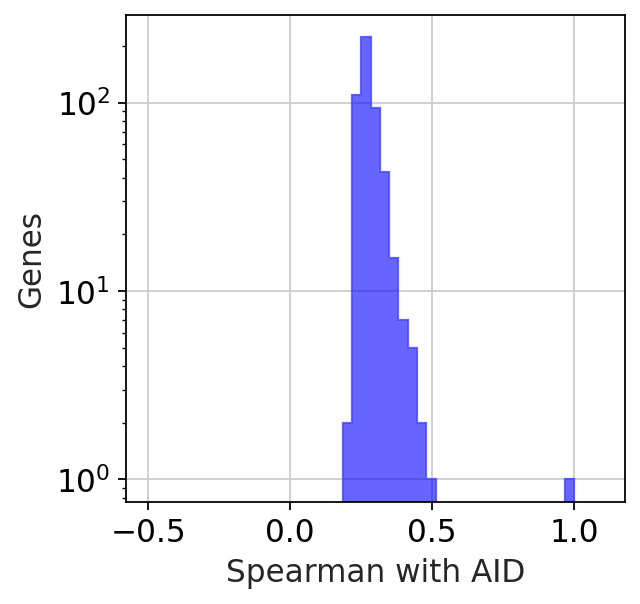

In [47]:
_df = df_spear

fig, ax = plt.subplots(1,1)

bins = np.linspace(-0.5, 1.1, 50)

plt.hist(_df[GOI], histtype='stepfilled', alpha = 0.6,color = 'b' ,bins = bins)
plt.hist(_df[GOI], histtype='step', alpha = 0.6, color = 'b', bins = bins)

plt.yscale('log')
plt.ylabel('Genes')
plt.xlabel('Spearman with AID')

In [48]:
TopCorrelatedGOI_GOIS = _df[GOI].index[:10]

In [49]:
TopCorrelatedGOI_GOI = _df[GOI].index[0]

In [50]:
genes2plot = TopCorrelatedGOI_GOIS.to_list()

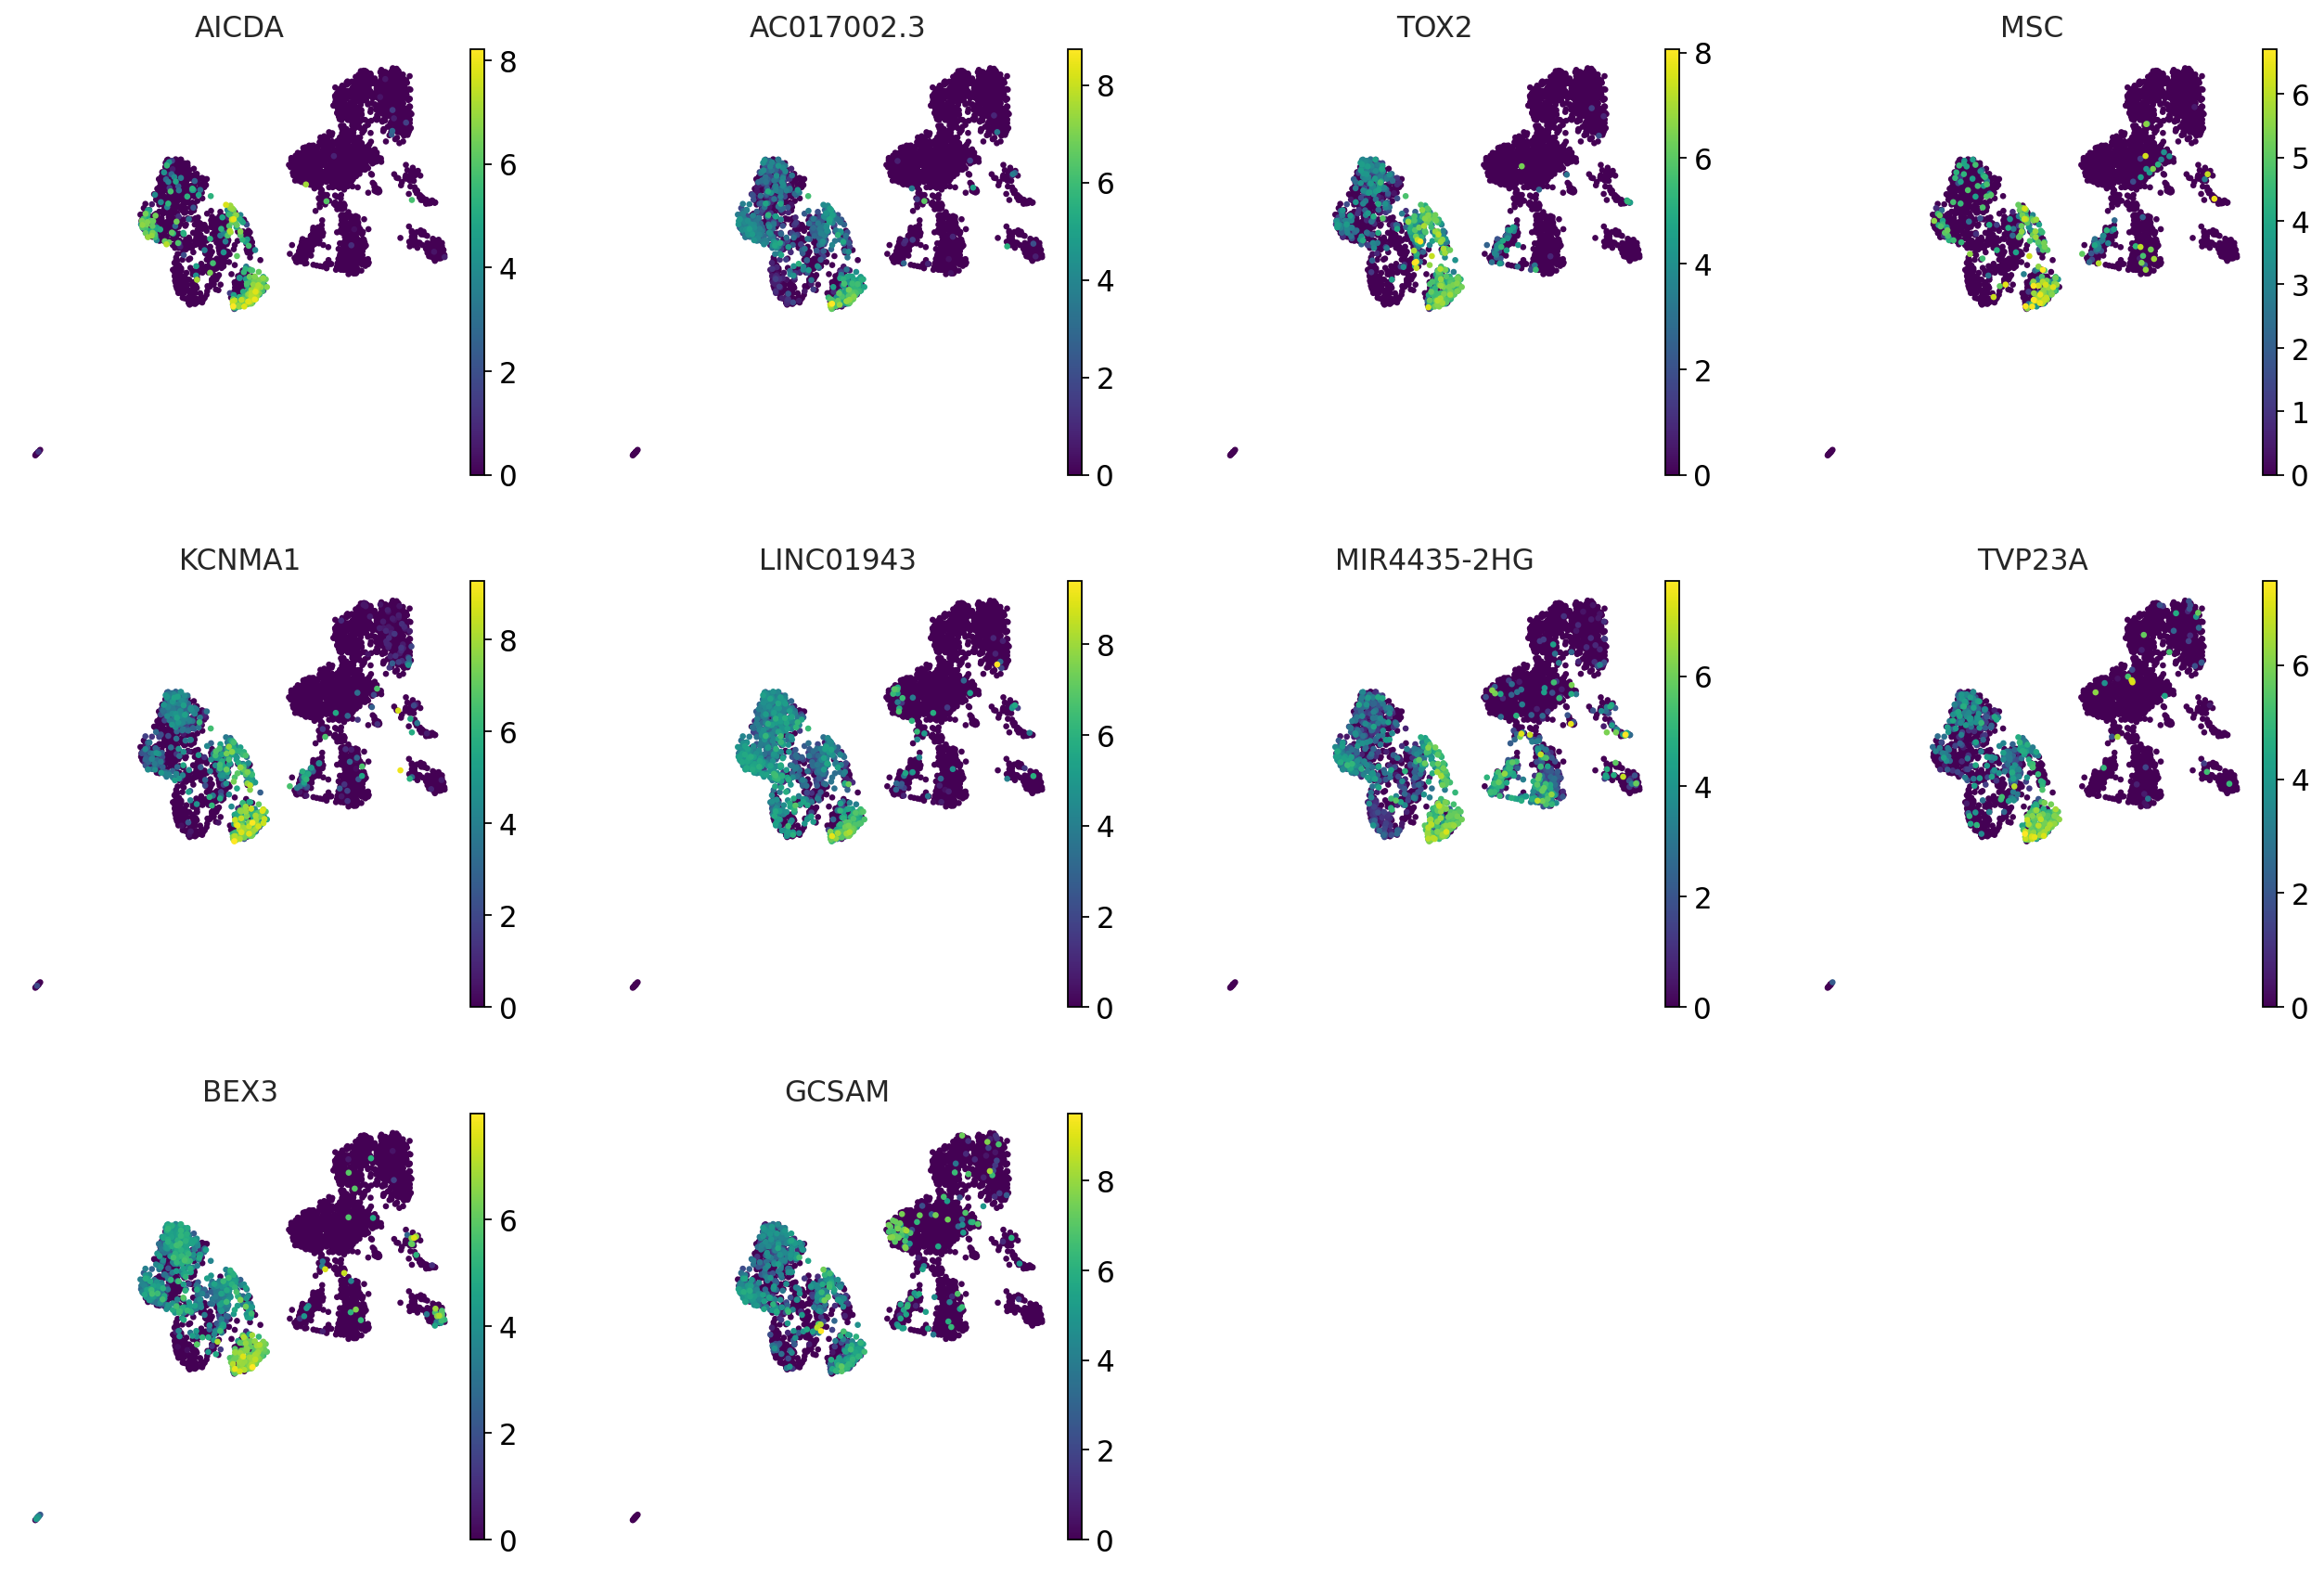

In [52]:
sc.pl.umap(adata, color = genes2plot, save = 'TopCorrAICDAgenes', frameon=False)

In [53]:
TopCorrelatedGOI_GOI = _df[GOI].index[5]

,WASH7P,FO538757.1,MTND1P23,MTND2P28,ENSG00000276171,MTCO1P12,MTCO2P12,MTATP8P1,MTATP6P1,MTCO3P12,AL669831.5,LINC01128,NOC2L,ISG15,AL390719.1,C1orf159,SDF4,B3GALT6,UBE2J2,PUSL1,INTS11,CPTP,AURKAIP1,CCNL2,AL391244.1,MRPL20,ATAD3B,ATAD3A,SSU72,MIB2,CDK11B,SLC35E2B,CDK11A,AL031282.2,SLC35E2,NADK,GNB1,FAAP20,MORN1,RER1,PEX10,PANK4,TNFRSF14-AS1,TNFRSF14,FAM213B,TPRG1L,WRAP73,TP73-AS1,LRRC47,CEP104,DFFB,C1orf174,KCNAB2,RPL22,ICMT,ACOT7,NOL9,AL591866.1,ZBTB48,KLHL21,PHF13,THAP3,DNAJC11,CAMTA1,VAMP3,TNFRSF9,PARK7,RERE,ENO1,HMGN2P17,SLC2A5,H6PD,SLC25A33,AL954705.1,TMEM201,PIK3CD,PIK3CD-AS2,CLSTN1,CTNNBIP1,LZIC,NMNAT1,UBE4B,KIF1B,PGD,CENPS,DFFA,PEX14,CASZ1,TARDBP,SRM,EXOSC10,MTOR,UBIAD1,FBXO44,FBXO6,MAD2L2,AGTRAP,MTHFR,CLCN6,KIAA2013,PLOD1,MFN2,MIIP,TNFRSF8,TNFRSF1B,VPS13D,HNRNPCL1,PRDM2,EFHD2,CASP9,DNAJC16,CHCHD2P6,DDI2,PLEKHM2,RPL12P14,UQCRHL,AL450998.1,AL450998.2,SPEN,ZBTB17,FBXO42,SZRD1,NECAP2,NBPF1,ENSG00000282056,CROCCP2,EIF1AXP1,CROCC,SDHB,RCC2,ALDH4A1,IFFO2,UBR4,EMC1,MRTO4,AKR7A2,PQLC2,CAPZB,MINOS1,AL031727.1,TMCO4,OTUD3,MUL1,DDOST,HP1BP3,EIF4G3,ECE1,NBPF3,ALPL,USP48,AL590556.1,LINC00339,CDC42,ZBTB40,KDM1A,LUZP1,HNRNPR,E2F2,ID3,RPL11,ELOA,PITHD1,LYPLA2,GALE,HMGCL,FUCA1,CNR2,AL590609.2,PNRC2,SRSF10,IFNLR1,STPG1,NIPAL3,RCAN3,SRRM1,CLIC4,RUNX3,SYF2,RSRP1,SDHDP6,TMEM50A,AL031284.1,MACO1,SELENON,MTFR1L,AUNIP,PAQR7,STMN1,CEP85,SH3BGRL3,UBXN11,CD52,DHDDS,AL513365.1,HMGN2,RPS6KA1,ARID1A,PIGV,ZDHHC18,GPN2,GPATCH3,NUDC,RPL12P13,OSTCP2,SLC9A1,CHCHD3P3,NPM1P39,WDTC1,TMEM222,ACTG1P20,SYTL1,MAP3K6,WASF2,AL031729.1,IFI6,FAM76A,STX12,PPP1R8,THEMIS2,RPA2,XKR8,EYA3,SPCS2P4,PTAFR,DNAJC8,ATP5IF1,SESN2,MED18,PHACTR4,RCC1,SNHG3,SNORA73B,TRNAU1AP,SNHG12,SNORD99,TAF12,GMEB1,YTHDF2,EPB41,AL138785.1,SRSF4,MECR,LAPTM5,PUM1,SNRNP40,ZCCHC17,PEF1,PTP4A2,KHDRBS1,TMEM39B,...,CBY1,TOMM22,JOSD1,GTPBP1,PRDX3P1,SUN2,CBX6,APOBEC3B,APOBEC3C,APOBEC3D,APOBEC3F,APOBEC3G,APOBEC3H,CBX7,RPL3,SYNGR1,TAB1,MGAT3,MIEF1,ATF4,RPS19BP1,UQCRFS1P1,Z82206.1,TNRC6B,ADSL,SGSM3,MKL1,SLC25A17,ST13,XPNPEP3,RBX1,AL080243.2,AL080243.1,EP300,L3MBTL2,RANGAP1,ZC3H7B,TOB2,PHF5A,ACO2,POLR3H,PMM1,DESI1,XRCC6,SNU13,C22orf46,MEI1,AL021453.1,SREBF2,TNFRSF13C,CENPM,NAGA,SNORD13P1,SMDT1,NDUFA6,OLA1P1,TCF20,RRP7A,RRP7BP,POLDIP3,CYB5R3,ATP5MGL,RPL5P34,ARFGAP3,PACSIN2,MCAT,TSPO,TTLL12,SAMM50,AL035398.1,PARVB,PARVG,RTL6,NUP50-AS1,NUP50,FAM118A,Z95331.1,ATXN10,PRR34-AS1,PPARA,CDPF1,TTC38,GTSE1,TRMU,CERK,AL118516.1,TBC1D22A,C22orf34,BRD1,ZBED4,ALG12,CRELD2,PIM3,TRABD,SELENOO,TUBGCP6,MAPK12,PLXNB2,DENND6B,PPP6R2,SBF1,ADM2,LMF2,NCAPH2,SCO2,TYMP,ODF3B,ARSA,AC002056.1,RPL23AP82,RABL2B,FP565260.6,FP565260.1,U2AF1L5,FP671120.3,FP671120.4,FP236383.2,FP236383.3,CR381670.1,TEKT4P2,EIF3FP1,ANKRD20A11P,AP001347.1,HSPA13,SAMSN1,NRIP1,USP25,BTG3,C21orf91,PPIAP22,EEF1A1P1,LINC01684,RPL13AP7,LINC00158,MIR155HG,MRPL39,JAM2,ATP5PF,GABPA,APP,GPX1P2,RPL10P1,N6AMT1,LTN1,RWDD2B,USP16,CCT8,BACH1,TIAM1,SOD1,SCAF4,MIS18A,URB1,URB1-AS1,C21orf59,SYNJ1,PAXBP1,IFNAR2,IL10RB,IFNAR1,IFNGR2,TMEM50B,GART,SON,DONSON,CRYZL1,ATP5PO,MRPS6,SLC5A3,RCAN1,CLIC6,RUNX1,SETD4,CBR1,MEMO1P1,CBR3-AS1,DOPEY2,MORC3,CHAF1B,CLDN14,HLCS,PIGP,TTC3,VPS26C,DYRK1A,PSMG1,BRWD1,HMGN1,WRB,MX2,MX1,PRDM15,ZBTB21,ZNF295-AS1,SLC37A1,WDR4,NDUFV3,PKNOX1,U2AF1,RRP1B,PDXK,CSTB,RRP1,AGPAT3,TRAPPC10,H2AFZP1,PWP2,C21orf33,PFKL,C21orf2,UBE2G2,SUMO3,PTTG1IP,ITGB2,ITGB2-AS1,FAM207A,ADARB1,SLC19A1,SPATC1L,LSS,MCM3AP-AS1,MCM3AP,YBEY,C21orf58,PCNT,DIP2A,PRMT2,MT-RNR1,MT-RNR2,MT-TL1,MT-ND1,MT-ND2,MT-TC,MT-TY,MT-CO1,MT-CO2,MT-ATP8,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,MT-TP,ENSG00000277048,AL592183.1,AC004556.1,AC240274.1
cell,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

Text(0, 0.5, 'LINC01943')

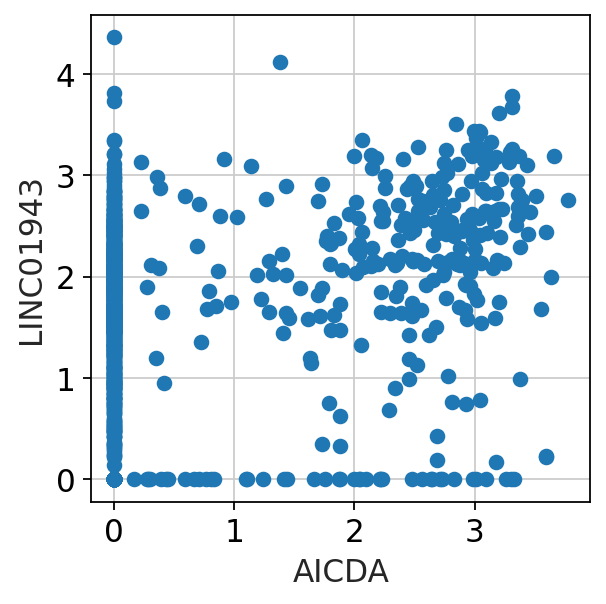

In [54]:
x, y = gene_df[GOI], gene_df[TopCorrelatedGOI_GOI]

fig, ax = plt.subplots(1,1)

plt.scatter(x,y)

plt.xlabel(GOI)
plt.ylabel(TopCorrelatedGOI_GOI)

### Transcription Factor Data online

In [55]:
DictofSerGenesrGenes = DictofSerGenes[GOI].index

In [56]:
df_TF = pd.read_csv('../../../SharedData/MetaData/TFs.csv', index_col = 0)

df_TF[df_TF['HGNC symbol'] == 'TOX2']['Final Comments'].to_list()

df_knownTFs = df_TF[df_TF['Is TF?'] == 'Yes']

TFs = set(df_knownTFs['HGNC symbol'].to_list()) & set(CorrGenes)  

TopKnownTfs = DictofSerGenes['AICDA'][DictofSerGenes['AICDA'].index.isin(TFs)]

In [57]:
df_TF.head()

,Ensembl ID,HGNC symbol,DBD,Is TF?,TF assessment,Binding mode,Motif status,Final Notes,Final Comments,Interpro ID(s),EntrezGene ID,EntrezGene Description,PDB ID,TF tested by HT-SELEX?,TF tested by PBM?,Conditional Binding Requirements,Original Comments,Vaquerizas 2009 classification,CisBP considers it a TF?,TFCat classification,Is a GO TF?,Initial assessment,Curator 1,Curator 2,TFclass considers it a TF?,Go Evidence,Pfam Domains (By ENSP ID),Is C2H2 ZF(KRAB)?
0,ENSG00000137203,TFAP2A,AP-2,Yes,Known motif,Monomer or homomultimer,High-throughput in vitro,None,None,IPR008121;IPR013854,7020,transcription factor AP-2 alpha [Source:HGNC S...,None,DBD,Yes,None,None,a,Yes,TF Gene_DNA-Binding: sequence-specific_DNA Bin...,Yes,"1a1, Direct HQ evidence",Sam Lambert,Yimeng Yin,Yes,$#ENSG00000137203#GO:0000981#sequence-specific...,$#ENSP00000368928#ENSG00000137203#ENST00000379...,False
1,ENSG00000008196,TFAP2B,AP-2,Yes,Known motif,Monomer or homomultimer,High-throughput in vitro,None,None,IPR008122;IPR013854,7021,transcription factor AP-2 beta [Source:HGNC Sy...,None,DBD,Yes,None,None,a,Yes,TF Gene_DNA-Binding: sequence-specific_DNA Bin...,Yes,"1a1, Direct HQ evidence",Matt Weirauch,Yimeng Yin,Yes,$#ENSG00000008196#GO:0000981#sequence-specific...,$#ENSP00000377265#ENSG00000008196#ENST00000393...,False
2,ENSG00000087510,TFAP2C,AP-2,Yes,Known motif,Monomer or homomultimer,High-throughput in vitro,None,None,IPR008123;IPR013854,7022,transcription factor AP-2 gamma [Source:HGNC S...,None,DBD and Full,Yes,None,None,a,Yes,No,Yes,"1a1, Direct HQ evidence",Matt Weirauch,Yimeng Yin,Yes,$#ENSG00000087510#GO:0001077#RNA polymerase II...,$#ENSP00000201031#ENSG00000087510#ENST00000201...,False
3,ENSG00000008197,TFAP2D,AP-2,Yes,Known motif,Monomer or homomultimer,In vivo/Misc source,Only known motifs are from Transfac or HocoMoc...,Binds the same GCCTGAGGC sequence as the other...,IPR013854;,83741,transcription factor AP-2 delta [Source:HGNC S...,None,not tested,not tested,None,None,a,Yes,No,Yes,"2a1, Lower confidence direct evidence",Arttu Jolma,Sam Lambert,Yes,$#ENSG00000008197#GO:0000981#sequence-specific...,$#ENSP00000008391#ENSG00000008197#ENST00000008...,False
4,ENSG00000116819,TFAP2E,AP-2,Yes,Known motif,Monomer or homomultimer,High-throughput in vitro,None,None,IPR013854;,339488,transcription factor AP-2 epsilon [Source:HGNC...,None,Full,Yes,None,None,a,Yes,TF Gene_DNA-Binding: sequence-specific_DNA Bin...,Yes,"1a1, Direct HQ evidence",Sam Lambert,Laura Campitelli,Yes,$#ENSG00000116819#GO:0000981#sequence-specific...,$#ENSP00000362332#ENSG00000116819#ENST00000373...,False


In [49]:
genes2plot = list(AICDA_genes.index[:12])

KeyError: 'GL7'

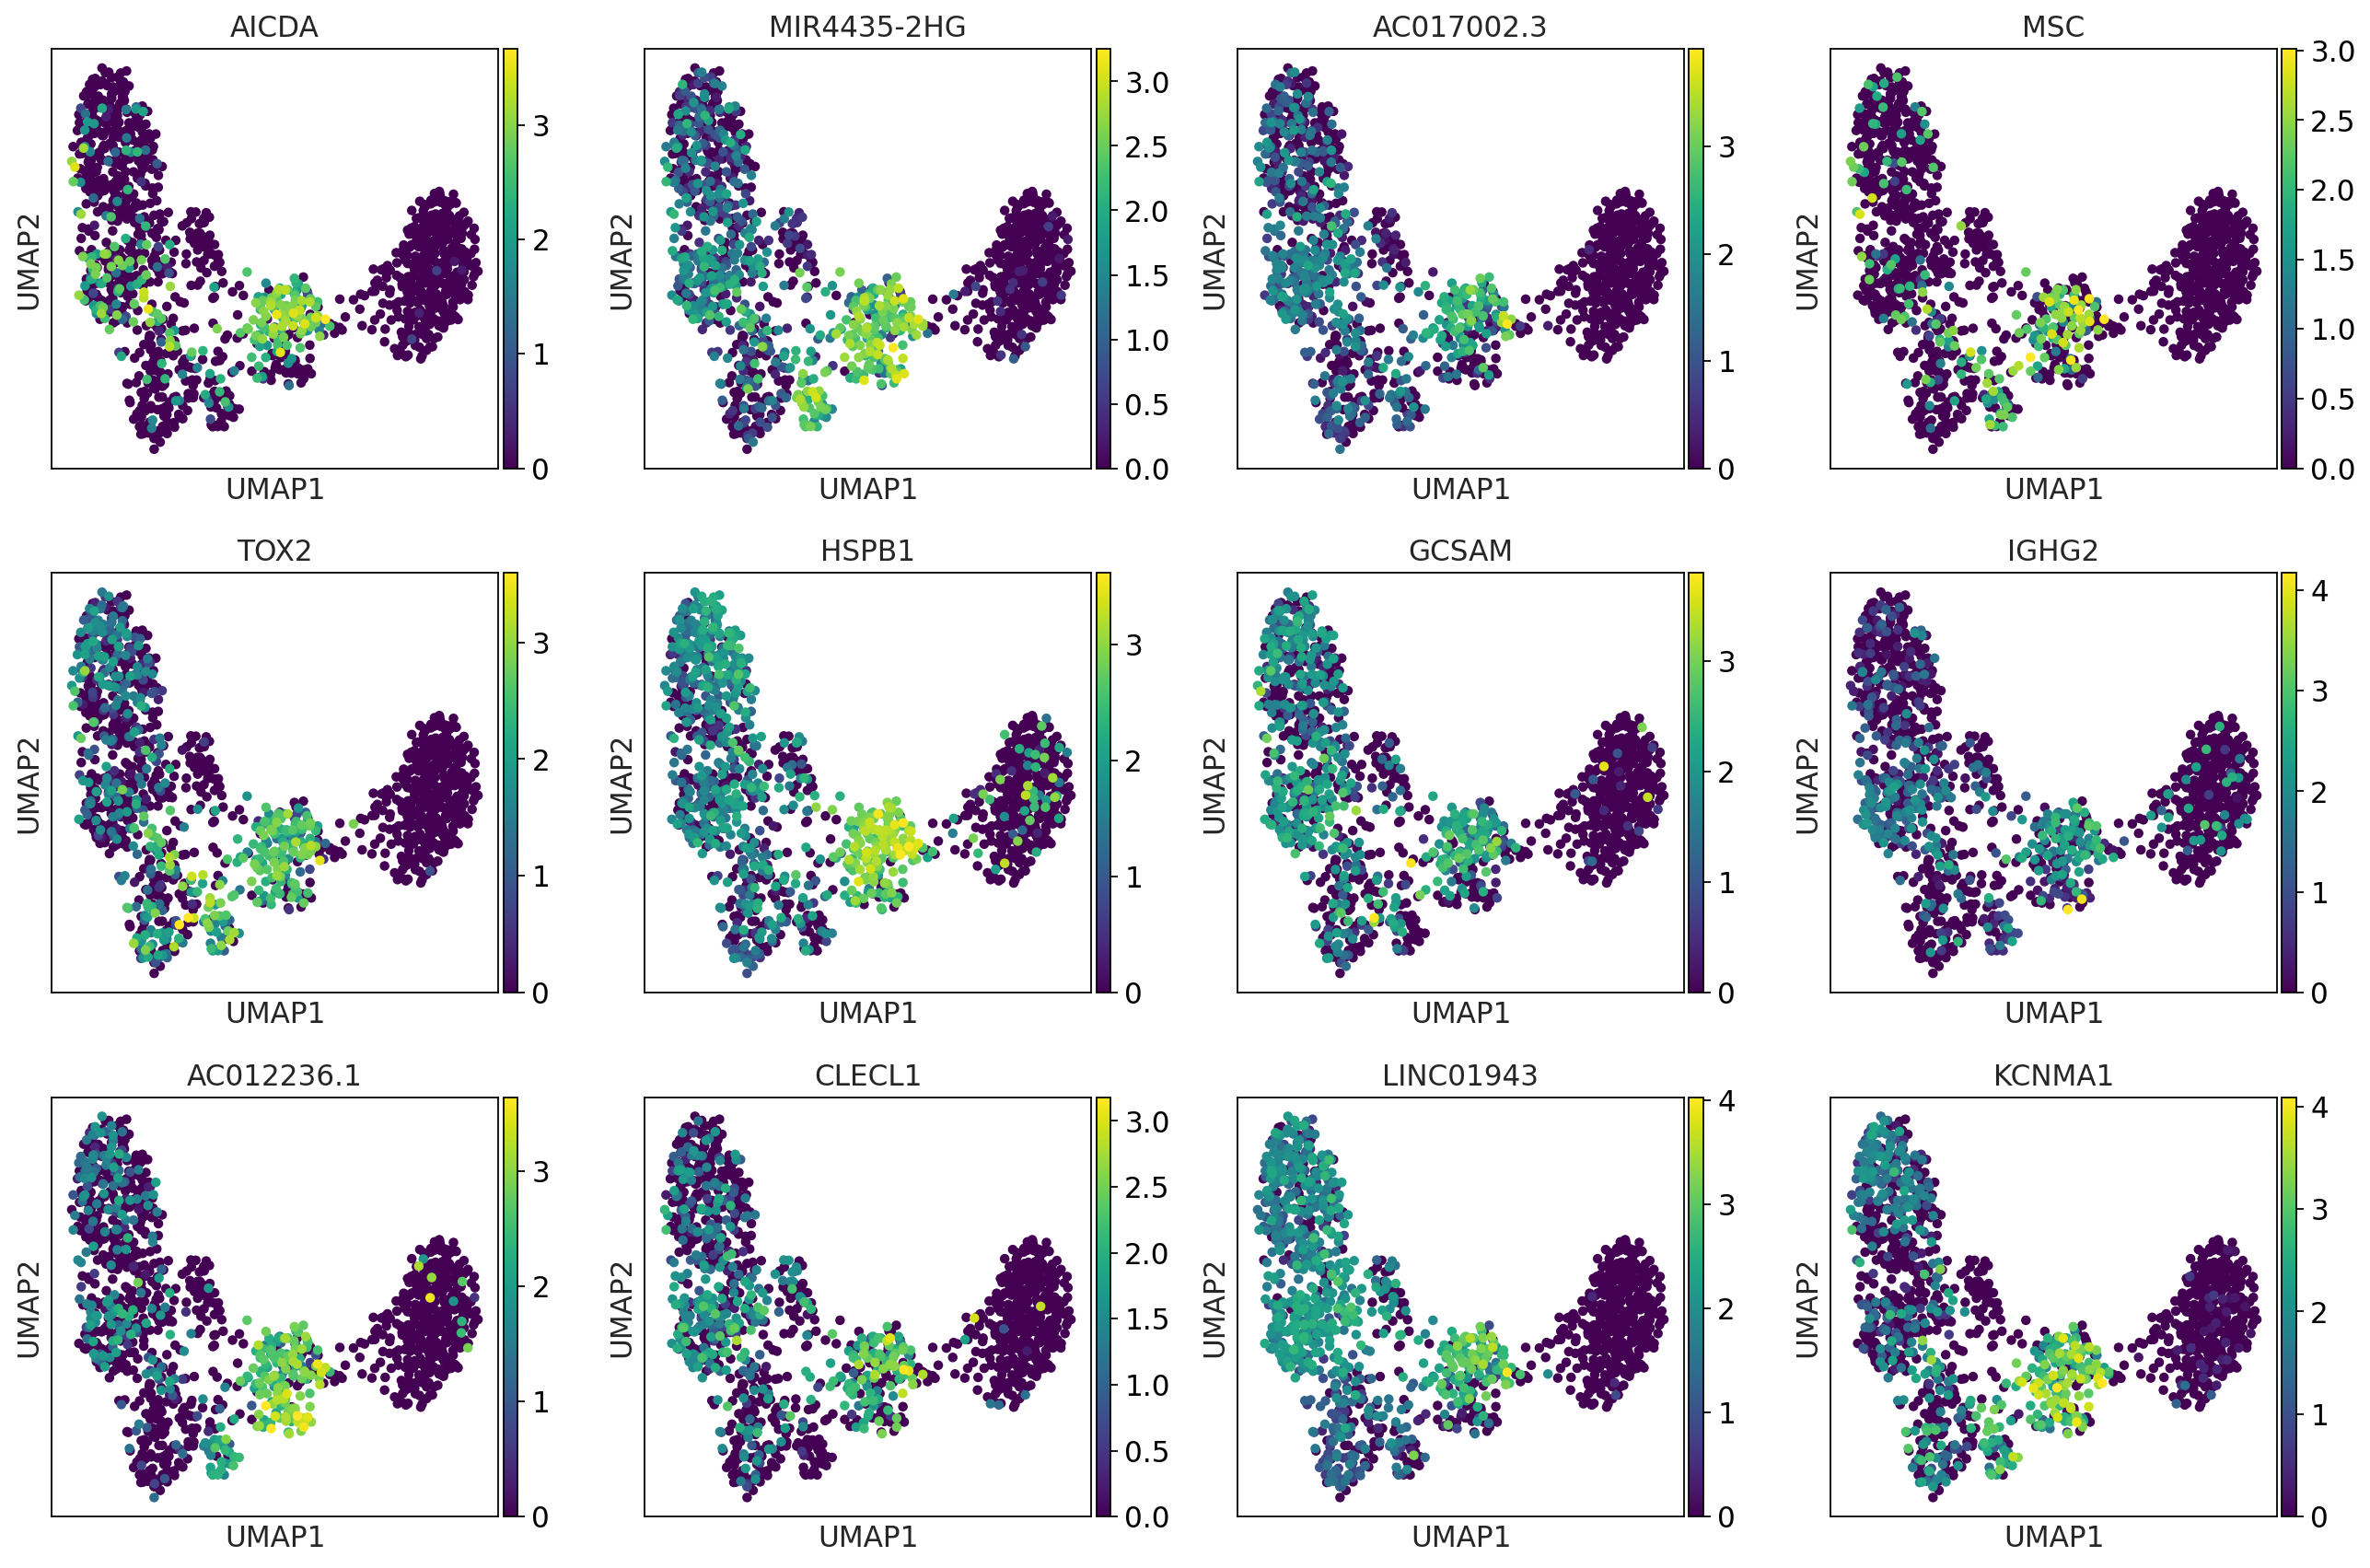

In [51]:

sc.pl.umap(adata, color = genes2plot + ['GL7'])